# 01 - Zone-Level Shooting Efficiency Analysis
Project: Finnish NHL Players - Zone-Level Shooting Efficiency Analysis

### Purpose
Statistical analysis of zone-level shooting efficiency differences
between Finnish NHL players and other nationalities. Builds on patterns
identified in 02_eda.ipynb and tests whether observed differences are
statistically meaningful.

### Input
- data/processed/shots_combined.csv

### Key questions
1. Are Finnish players' zone-level efficiency differences statistically significant?
2. Are the patterns consistent across all three seasons?
3. What are the confidence intervals around observed efficiency differences?

### Output
- Bootstrapped confidence intervals per nationality per zone
- Season-over-season consistency analysis
- Publication-ready visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DATA = Path('../data/processed')
df = pd.read_csv(PROCESSED_DATA / 'shots_combined.csv')

print(f"Dataset correctness check: {len(df)} rows, {df.shape[1]} columns")

Dataset correctness check: 338141 rows, 126 columns


### 02 - Data Preparation

In [2]:
def classify_zone(x_abs, y_abs):
    if x_abs < 25 or x_abs > 89:
        return 'excluded'
    elif x_abs <= 41:
        return 'blue_line'
    elif x_abs >= 76 and y_abs <= 10:
        return 'slot'
    else:
        return 'arc'

df['zone'] = df.apply(
    lambda row: classify_zone(
        row['arenaAdjustedXCordABS'],
        row['arenaAdjustedYCordAbs']
    ),
    axis=1
)

df = df.copy()

df_oz = df[df['zone'] != 'excluded'].copy()

print(f"Offensive zone shots: {len(df_oz)}")
print(f"Zone distribution:")
print(df_oz['zone'].value_counts())

C:\Users\juuso\AppData\Local\Temp\ipykernel_5752\2580782946.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['zone'] = df.apply(


Offensive zone shots: 322658
Zone distribution:
zone
arc          207618
slot          61663
blue_line     53377
Name: count, dtype: int64


# 03 - Zone-Level Efficiency and Bootstrapped Confidence Intervals

In [3]:
N_BOOTSTRAP = 1000
CONFIDENCE = 0.95
MIN_SHOTS_PER_ZONE = 1000
ZONES = ['slot', 'blue_line', 'arc']

def bootstrap_efficiency(goals, xg, N_BOOTSTRAP, CONFIDENCE):
    
    goals = np.array(goals)
    xg = np.array(xg)
    estimates = []
    
    for i in range(N_BOOTSTRAP):
        idx = np.random.choice(len(goals), size=len(goals), replace=True)
        g = goals[idx].sum()
        x = xg[idx].sum()
        estimates.append((g - x) / x)
    
    alpha = (1 - CONFIDENCE) / 2
    return np.quantile(estimates, alpha), np.quantile(estimates, 1 - alpha)

print(f"Parameters: {N_BOOTSTRAP} iterations, {CONFIDENCE*100:.0f}% confidence interval")
print(f"Minimum shots per zone: {MIN_SHOTS_PER_ZONE}")

Parameters: 1000 iterations, 95% confidence interval
Minimum shots per zone: 1000


In [4]:
results = []

for zone in ZONES:
    zone_data = df_oz[df_oz['zone'] == zone]
    
    for nationality, group in zone_data.groupby('nationality'):
        if len(group) < MIN_SHOTS_PER_ZONE:
            continue
        
        goals = group['goal'].values
        xg = group['xGoal'].values
        
        total_goals = goals.sum()
        total_xg = xg.sum()
        efficiency = (total_goals - total_xg) / total_xg
        
        ci_lower, ci_upper = bootstrap_efficiency(goals, xg, N_BOOTSTRAP, CONFIDENCE)
        
        results.append({
            'nationality': nationality,
            'zone': zone,
            'shots': len(group),
            'goals': total_goals,
            'xG': total_xg,
            'efficiency': efficiency,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })

results_df = pd.DataFrame(results)

# Normalize to NHL average per zone
nhl_avg = results_df.groupby('zone').apply(
    lambda x: (x['goals'].sum() - x['xG'].sum()) / x['xG'].sum()
).rename('nhl_avg')

results_df = results_df.merge(nhl_avg, on='zone')
results_df['efficiency_vs_nhl'] = results_df['efficiency'] - results_df['nhl_avg']
results_df['ci_lower_vs_nhl'] = results_df['ci_lower'] - results_df['nhl_avg']
results_df['ci_upper_vs_nhl'] = results_df['ci_upper'] - results_df['nhl_avg']

print(f"Nationalities included: {results_df['nationality'].nunique()}")
print(f"Finnish players per zone:")
print(results_df[results_df['nationality'] == 'FIN'][
    ['zone', 'shots', 'efficiency_vs_nhl', 'ci_lower_vs_nhl', 'ci_upper_vs_nhl']
].to_string(index=False))

Nationalities included: 10
Finnish players per zone:
     zone  shots  efficiency_vs_nhl  ci_lower_vs_nhl  ci_upper_vs_nhl
     slot   2752           0.055082        -0.019432         0.131892
blue_line   1992          -0.230517        -0.416053        -0.043013
      arc  10082          -0.010613        -0.087729         0.069048


# 04 - Season-over-season consistency

In [5]:
season_results = []

for season in [2022, 2023, 2024]:
    season_data = df_oz[df_oz['season'] == season]
    
    for zone in ZONES:
        zone_data = season_data[season_data['zone'] == zone]
        
        for nationality, group in zone_data.groupby('nationality'):
            if len(group) < 300:
                continue
            
            total_goals = group['goal'].sum()
            total_xg = group['xGoal'].sum()
            efficiency = (total_goals - total_xg) / total_xg
            
            season_results.append({
                'season': season,
                'nationality': nationality,
                'zone': zone,
                'shots': len(group),
                'goals': total_goals,
                'xG': total_xg,
                'efficiency': efficiency
            })

season_df = pd.DataFrame(season_results)

# Normalize to NHL average per season per zone
season_nhl_avg = season_df.groupby(['season', 'zone']).apply(
    lambda x: (x['goals'].sum() - x['xG'].sum()) / x['xG'].sum()
).rename('nhl_avg').reset_index()

season_df = season_df.merge(season_nhl_avg, on=['season', 'zone'])
season_df['efficiency_vs_nhl'] = season_df['efficiency'] - season_df['nhl_avg']

fin_seasons = season_df[season_df['nationality'] == 'FIN'].sort_values(['zone', 'season'])
print(fin_seasons[['zone', 'season', 'shots', 'efficiency_vs_nhl']].to_string(index=False))

     zone  season  shots  efficiency_vs_nhl
      arc    2022   3462           0.038343
      arc    2023   3275          -0.109669
      arc    2024   3345           0.030679
blue_line    2022    704          -0.098300
blue_line    2023    652          -0.302867
blue_line    2024    636          -0.322615
     slot    2022   1003           0.048809
     slot    2023    879           0.092861
     slot    2024    870           0.023039


# 04 - Visualizations

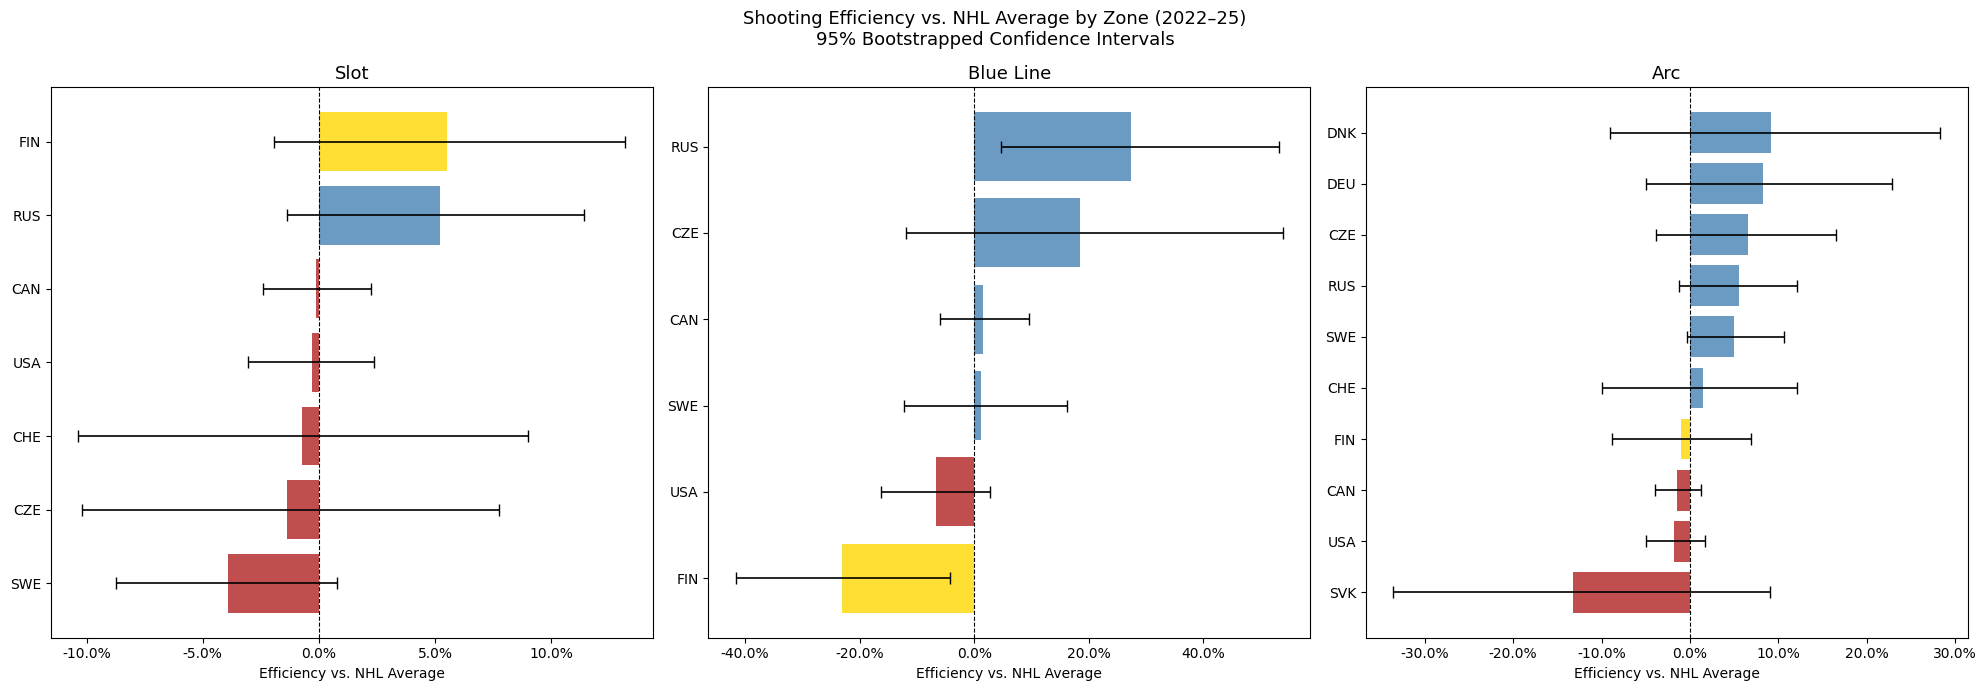

Chart saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
zone_labels = {'slot': 'Slot', 'blue_line': 'Blue Line', 'arc': 'Arc'}

for i, zone in enumerate(ZONES):
    ax = axes[i]
    zone_data = results_df[results_df['zone'] == zone].sort_values(
        'efficiency_vs_nhl', ascending=True
    )

    colors = ['gold' if n == 'FIN' else
              'steelblue' if x >= 0 else
              'firebrick'
              for n, x in zip(zone_data['nationality'], zone_data['efficiency_vs_nhl'])]

    ax.barh(zone_data['nationality'], zone_data['efficiency_vs_nhl'], color=colors, alpha=0.8)

    ax.errorbar(
        zone_data['efficiency_vs_nhl'],
        range(len(zone_data)),
        xerr=[
            zone_data['efficiency_vs_nhl'] - zone_data['ci_lower_vs_nhl'],
            zone_data['ci_upper_vs_nhl'] - zone_data['efficiency_vs_nhl']
        ],
        fmt='none',
        color='black',
        capsize=4,
        linewidth=1.2
    )

    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(zone_labels[zone], fontsize=13)
    ax.set_xlabel('Efficiency vs. NHL Average')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

plt.suptitle(
    'Shooting Efficiency vs. NHL Average by Zone (2022–25)\n95% Bootstrapped Confidence Intervals',
    fontsize=13
)
plt.tight_layout()
plt.savefig('../visualizations/04_zone_efficiency_with_ci.png', dpi=150)
plt.show()
print("Chart saved.")

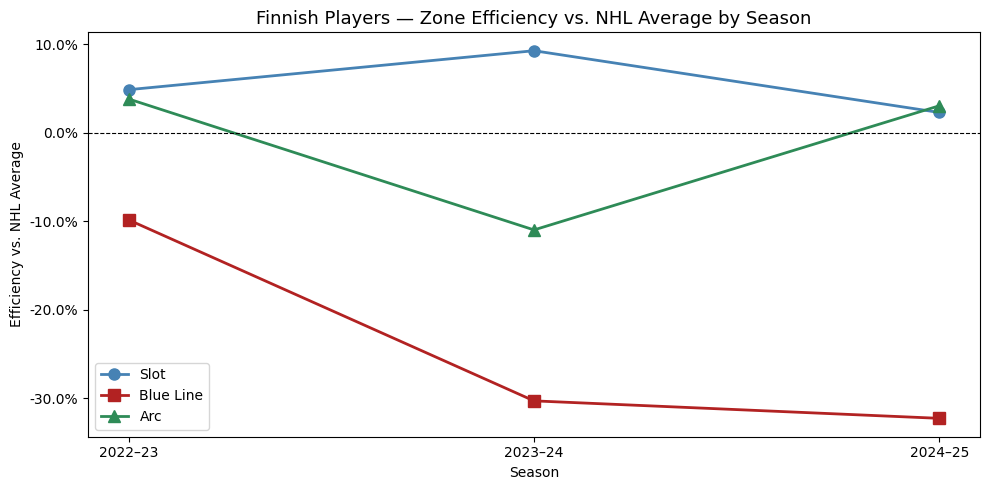

Chart saved.


In [7]:
fin_season = season_df[season_df['nationality'] == 'FIN'].copy()

fig, ax = plt.subplots(figsize=(10, 5))

colors = {'slot': 'steelblue', 'blue_line': 'firebrick', 'arc': 'seagreen'}
markers = {'slot': 'o', 'blue_line': 's', 'arc': '^'}
labels = {'slot': 'Slot', 'blue_line': 'Blue Line', 'arc': 'Arc'}

season_labels = {2022: '2022–23', 2023: '2023–24', 2024: '2024–25'}
x_positions = [0, 1, 2]

for zone in ZONES:
    zone_data = fin_season[fin_season['zone'] == zone].sort_values('season')
    ax.plot(
        x_positions,
        zone_data['efficiency_vs_nhl'].values,
        color=colors[zone],
        marker=markers[zone],
        linewidth=2,
        markersize=8,
        label=labels[zone]
    )

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x_positions)
ax.set_xticklabels(['2022–23', '2023–24', '2024–25'])
ax.set_xlabel('Season')
ax.set_ylabel('Efficiency vs. NHL Average')
ax.set_title('Finnish Players — Zone Efficiency vs. NHL Average by Season', fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()

plt.tight_layout()
plt.savefig('../visualizations/05_finnish_season_consistency.png', dpi=150)
plt.show()
print("Chart saved.")

## 5. Summary and Conclusions

### Key Findings

Blue Line — Statistically Significant Weakness

Finnish NHL players show a consistent and statistically significant 
underperformance from the blue line zone (xABS 25–41) relative to the 
NHL average:
- Three-season average: -23.1% vs. NHL average
- 95% confidence interval: [-42.2%, -2.4%] — does not cross zero
- Pattern is consistent and worsening across all three seasons:
  2022–23: -9.8%, 2023–24: -30.3%, 2024–25: -32.3%
- Finnish players rank last among all nationalities with appropriate amount of shots in blue line efficiency

Slot — Non-Significant Positive Tendency

Finnish players show a positive tendency from the slot (xABS ≥ 76, yABS ≤ 10):
- Three-season average: +5.5% vs. NHL average
- 95% confidence interval: [-1.7%, +13.2%] — crosses zero
- Not statistically significant but consistent across all three seasons
- Finnish players rank 1st among all nationalities in slot efficiency

Arc — No Meaningful Pattern
Finnish players perform close to NHL average from the arc:
- Three-season average: -1.1% vs. NHL average
- 95% confidence interval: [-8.6%, +6.4%] — crosses zero
- Inconsistent across seasons — not a structural pattern

### Implications for Finnish Player Development

The blue line finding is the most actionable result of this analysis.
Finnish players systematically underperform from the blue line relative
to all other major hockey nations — and this gap is widening over time.

This suggests a potential structural weakness in how Finnish players
develop and execute blue line shots. Possible explanations include:
- Positional tendencies (fewer defensemen with high shot volume)
- Shot selection or execution from distance
- Differences in power play systems that emphasize blue line shooting

Important caveat: This analysis establishes correlation, not causation.
The observed patterns reflect what the data shows — not why it happens.
Additional qualitative research would be needed to identify root causes.

### Statistical Notes
- All efficiency metrics normalized to NHL average per zone to correct
  for systematic xG model bias
- Minimum threshold: 1000 shots per nationality per zone
- Bootstrapped confidence intervals: 1000 iterations, 95% level
- Seasons covered: 2022–23, 2023–24, 2024–25 (regular season only)

### Possible Next Steps
- Investigate blue line underperformance by shot type (slap vs. wrist)
- Examine whether pattern is driven by forwards or defensemen
- Compare with historical data beyond three seasons